In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Split
#    ↓
# Fill nulls
#    ↓
# Outlier handling
#    ↓
# Scaling
#    ↓
# Feature Selection
#    ↓
# PCA (optional)
#    ↓
# SMOTE
#    ↓
# Model

In [ ]:
def remove_nuls(x_train, x_test):
  # df.loc[:,df.isnull().sum()>0]
  #def simple imputers
  from sklearn.impute import SimpleImputer
  for i in df.columns[df.isnull().sum()>0]:
    si=SimpleImputer(strategy="mean")
    x_train[i]=si.fit_transform(x_train[[i]])
    x_test[i]=si.transform(x_test[[i]])

  return (x_train, x_test)

In [ ]:
def remove_outlier(x_train, x_test):
  !pip install feature-engine
  from feature_engine.outliers import Winsorizer
  winsor = Winsorizer(
    capping_method="quantiles",
    tail="both",
    fold=0.01
)

  for col in x_train.columns.to_list():

    x_train[col] = winsor.fit_transform(x_train[[col]])
    x_test[col] = winsor.transform(x_test[[col]])

  return (x_train, x_test)

In [ ]:
def scale_data(x_train, x_test):
  from sklearn.preprocessing import StandardScaler
  ss=StandardScaler()
  for i in x_train.columns.to_list():
    x_train[i]=ss.fit_transform(x_train[[i]])
    x_test[i]=ss.transform(x_test[[i]])

  return(x_train, x_test)

In [ ]:
def feature_select(x_train, y_train):
  from sklearn.feature_selection import SelectKBest
  from sklearn.feature_selection import mutual_info_classif

  selector = SelectKBest(
      score_func=mutual_info_classif,
      k=5
  )

  x_train_new = selector.fit_transform(
      x_train,
      y_train
  )

  selected_features = x_train.columns[
      selector.get_support()
  ]

  return selected_features

In [ ]:
def decompose(x_train, x_test):
  from sklearn.decomposition import PCA
  pca=PCA(n_components=2)
  x_train=pca.fit_transform(x_train)
  x_test=pca.transform(x_test)

  return (x_train, x_test)

In [ ]:
def clear_imbalance(x_train, y_train):
  from imblearn.over_sampling import RandomOverSampler
  os=RandomOverSampler()

  x_train_sampled, y_train_sampled = os.fit_resample(x_train, y_train)

  return (x_train_sampled, y_train_sampled)

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/AI Training/Datasets/Copy of water_potability.csv')

In [ ]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=df.iloc[ : , :-1]
y=df.iloc[:,-1]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, stratify=y)

In [ ]:
x_train.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
2117,8.575939,215.136721,15778.729396,7.532773,316.959490,359.830073,14.944675,79.463992,4.002129
1971,6.333640,185.436340,18506.288609,6.572682,356.971033,366.813108,16.439629,76.764385,3.982002
69,7.261551,179.889788,24964.777703,5.837086,349.269271,501.182781,17.287713,50.993006,3.636364
1595,6.917858,200.705505,27651.609099,6.529774,321.696455,453.637510,11.283387,91.942181,5.544167
1166,5.716251,184.229295,19393.469862,5.299164,290.276455,502.993687,19.643896,68.236370,3.433135


In [ ]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
xtrain_arr=[]
xtest_arr=[]
ytrain_arr=[]
ytest_arr=[]

acc=[]

In [ ]:
from sklearn.svm import SVC
skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report


In [ ]:
for i in range(6)[1:]:
  print(i)


1
2
3
4
5


In [ ]:
xtrain_arr=[]
xtest_arr=[]
ytrain_arr=[]
ytest_arr=[]

acc=[]
for trainindex, testindex in skf.split(x,y):

      x_train=x.iloc[trainindex]
      x_test=x.iloc[testindex]

      y_train=y.iloc[trainindex]
      y_test=y.iloc[testindex]

      xtrain_arr.append(x_train)
      xtest_arr.append(x_test)
      ytrain_arr.append(y_train)
      ytest_arr.append(y_test)
      ind=[]
      for i in range(6)[1:]:

          x_train, x_test=remove_nuls(x_train, x_test)
          if i!=1:
            x_train, x_test=remove_outlier(x_train, x_test)
          elif i!=2:
            x_train, x_test = scale_data(x_train, x_test)
          elif i!=3:
            features = feature_select(x_train, y_train)
            x_train=x_train[features]
            x_test=x_test[features]
          elif i!=4:
            x_train, x_test = decompose(x_train, x_test)
          elif i!=5:
            x_train, y_train = clear_imbalance(x_train, y_train)

          model_svc=SVC(kernel='rbf',C=10,
              gamma='scale',
              class_weight='balanced')

          model_svc.fit(x_train, y_train)
          y_pred=model_svc.predict(x_test)

          print('accuracy_score')
          a=accuracy_score(y_test, y_pred)
          print(a)
          ind.append((a,i))
          print()
      acc.append(ind)
          # 'printconfusion_matrix'
          # print(confusion_matrix(y_test, y_pred))
          # print()
          # print('classification_report')
          # print(classification_report(y_test, y_pred))

print(acc)

/tmp/ipykernel_15740/1078575300.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train[i]=si.fit_transform(x_train[[i]])
/tmp/ipykernel_15740/1078575300.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[i]=si.transform(x_test[[i]])
/tmp/ipykernel_15740/1078575300.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

accuracy_score
0.6554878048780488



/tmp/ipykernel_15740/1078575300.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train[i]=si.fit_transform(x_train[[i]])
/tmp/ipykernel_15740/1078575300.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[i]=si.transform(x_test[[i]])
/tmp/ipykernel_15740/1078575300.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

/tmp/ipykernel_15740/3642796225.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train[col] = winsor.fit_transform(x_train[[col]])
/tmp/ipykernel_15740/3642796225.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[col] = winsor.transform(x_test[[col]])
/tmp/ipykernel_15740/3642796225.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

accuracy_score
0.6539634146341463



...

/tmp/ipykernel_15740/3642796225.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train[col] = winsor.fit_transform(x_train[[col]])
/tmp/ipykernel_15740/3642796225.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[col] = winsor.transform(x_test[[col]])
/tmp/ipykernel_15740/3642796225.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

accuracy_score
0.648854961832061



/tmp/ipykernel_15740/1078575300.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train[i]=si.fit_transform(x_train[[i]])
/tmp/ipykernel_15740/1078575300.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[i]=si.transform(x_test[[i]])
/tmp/ipykernel_15740/1078575300.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

/tmp/ipykernel_15740/3642796225.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train[col] = winsor.fit_transform(x_train[[col]])
/tmp/ipykernel_15740/3642796225.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[col] = winsor.transform(x_test[[col]])
/tmp/ipykernel_15740/3642796225.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

accuracy_score
0.648854961832061

[[(0.6554878048780488, 1), (0.6539634146341463, 2), (0.6539634146341463, 3), (0.6539634146341463, 4), (0.6539634146341463, 5)], [(0.6595419847328244, 1), (0.6610687022900763, 2), (0.6595419847328244, 3), (0.6595419847328244, 4), (0.6595419847328244, 5)], [(0.6244274809160305, 1), (0.6198473282442748, 2), (0.6198473282442748, 3), (0.6198473282442748, 4), (0.6198473282442748, 5)], [(0.6229007633587786, 1), (0.6274809160305344, 2), (0.6274809160305344, 3), (0.6274809160305344, 4), (0.6274809160305344, 5)], [(0.6351145038167939, 1), (0.6519083969465649, 2), (0.650381679389313, 3), (0.648854961832061, 4), (0.648854961832061, 5)]]


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Model
model = SVC()

# Parameters
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"]
}

# Grid Search
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    verbose=2,
    n_jobs=-1
)
x_train, x_test=remove_nuls(x_train, x_test)

# Train
grid.fit(x_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predict
y_pred = best_model.predict(
    x_test
)

# Results
print("Best Params:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)
print("\nCV results")
print(grid.cv_results_)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [ ]:
x_train.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
2117,8.575939,215.136721,15778.729396,7.532773,316.959490,359.830073,14.944675,79.463992,4.002129
1971,6.333640,185.436340,18506.288609,6.572682,356.971033,366.813108,16.439629,76.764385,3.982002
69,7.261551,179.889788,24964.777703,5.837086,349.269271,501.182781,17.287713,50.993006,3.636364
1595,6.917858,200.705505,27651.609099,6.529774,321.696455,453.637510,11.283387,91.942181,5.544167
1166,5.716251,184.229295,19393.469862,5.299164,290.276455,502.993687,19.643896,68.236370,3.433135


In [ ]:
x_test.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
2487,1.584888,1.743821,-1.010550,-0.591489,-0.399815,-0.977550,-0.361917,-0.475409,-0.250284
968,0.536304,0.257033,-1.883964,-0.820160,0.264768,0.049526,0.209344,-0.660085,0.730801
413,-0.948683,-0.262999,0.580307,-0.572985,-0.455546,0.875155,-1.435089,-0.819620,-0.840178
392,-0.301207,0.093971,-0.689285,-1.178044,0.351746,-1.008312,0.533142,-0.322235,-2.260401
2482,0.554321,1.220170,-1.900435,-0.397962,-0.001052,0.197562,-0.651422,-2.075700,1.806322


In [ ]:
x_train.isnull().sum()

,0
ph,366
Hardness,0
Solids,0
Chloramines,0
Sulfate,591
Conductivity,0
Organic_carbon,0
Trihalomethanes,125
Turbidity,0


In [ ]:
def find_outlier(df):
  import math
  import numpy as np
  import seaborn as sns
  import matplotlib.pyplot as plt

  cols=df.columns.tolist()
  x=int(np.ceil(np.sqrt(len(cols))))
  fig,ax = plt.subplots(x,x, figsize=(x*5, x*5))

  for i in range(len(cols)):
    plt.subplot(x,x,i+1)
    sns.boxplot(df[cols[i]])

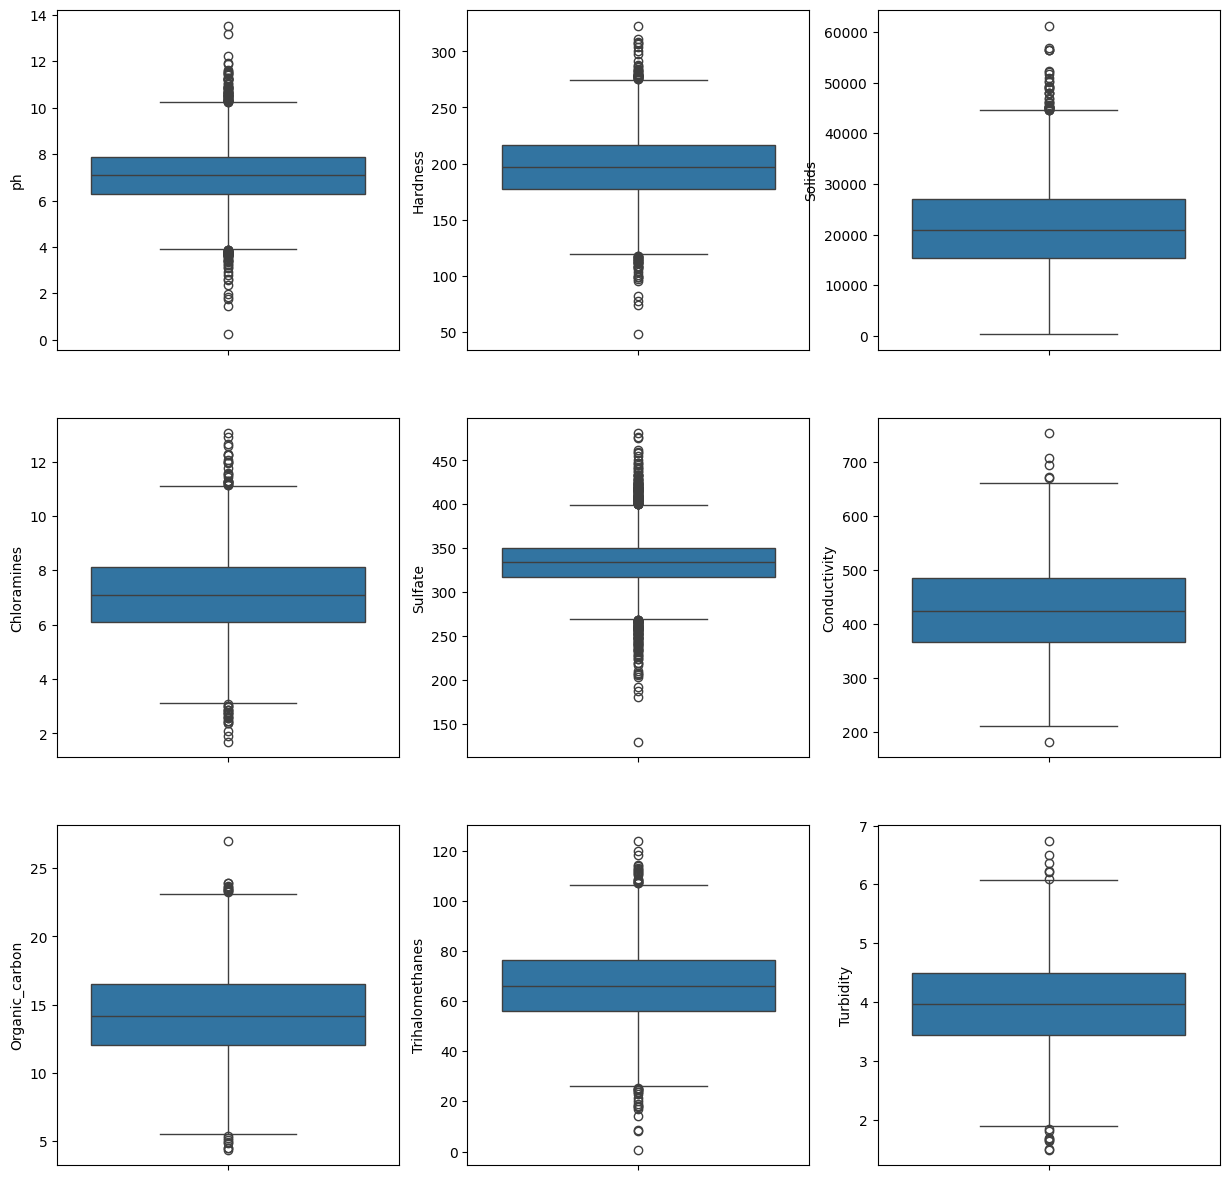

In [ ]:
find_outlier(x_train)

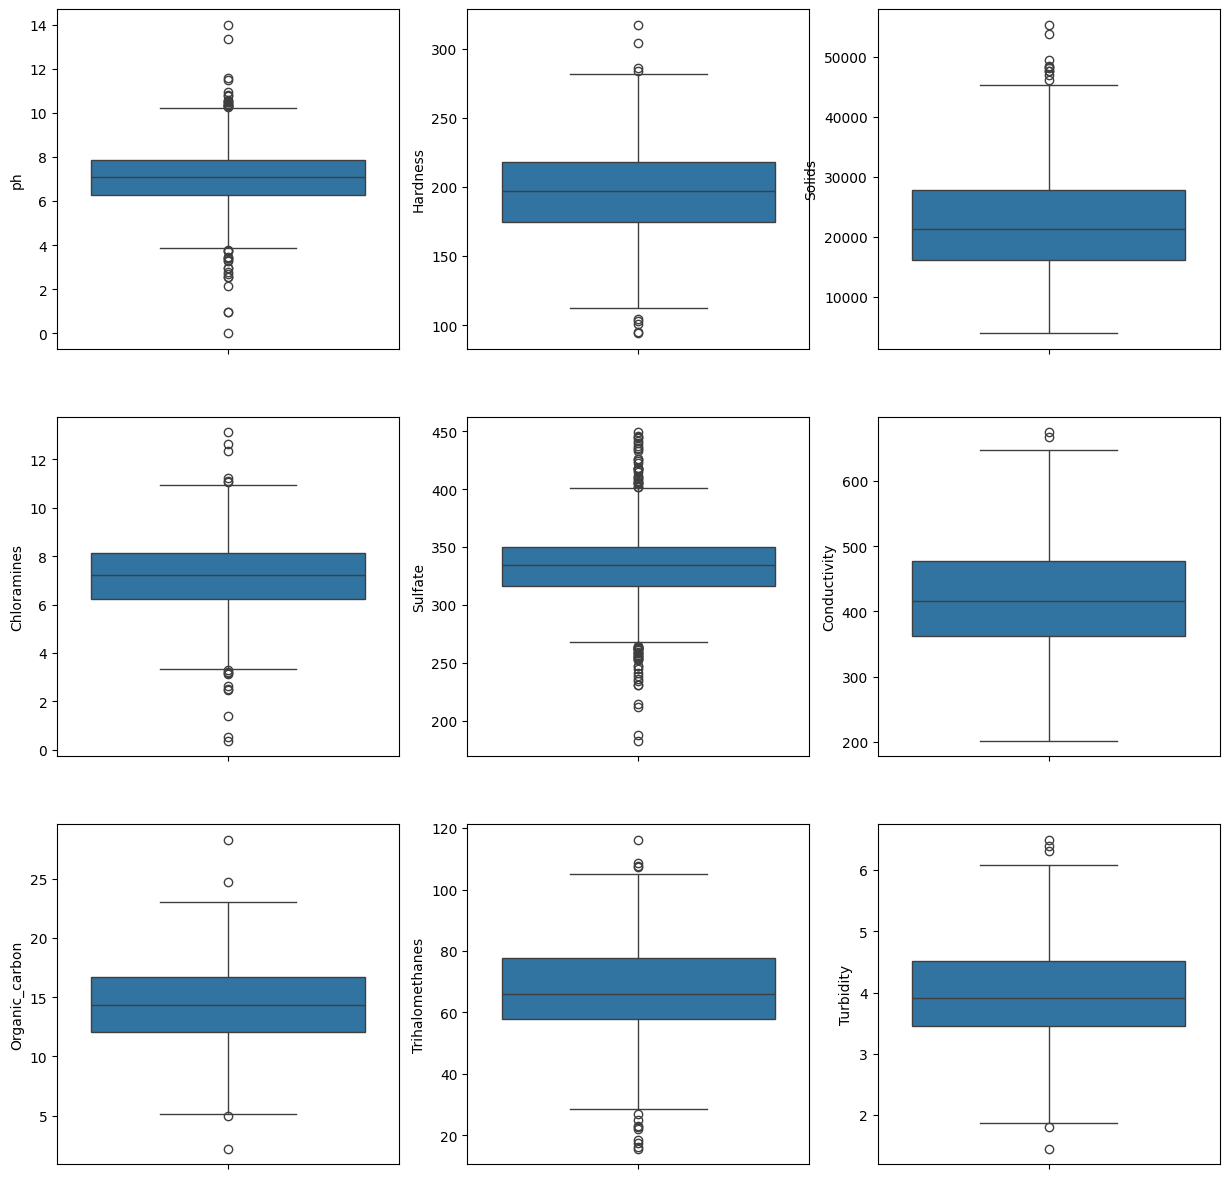

In [ ]:
find_outlier(x_test)

In [ ]:
x_train, x_test=remove_outlier(x_train,x_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

model = RandomForestClassifier()

model.fit(x_train, y_train)

importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

           Feature  Importance
0               ph    0.131294
4          Sulfate    0.126484
1         Hardness    0.119709
3      Chloramines    0.117272
2           Solids    0.112633
5     Conductivity    0.101085
8        Turbidity    0.097912
6   Organic_carbon    0.097518
7  Trihalomethanes    0.096092


Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity'],
      dtype='object')


In [ ]:
x_train=x_train[['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate']]

In [ ]:
x_test=x_test[['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate']]

In [ ]:
x_train.head()

,ph,Hardness,Solids,Chloramines,Sulfate
2117,1.041611,0.582022,-0.703715,0.278675,-0.496105
1971,-0.533232,-0.350271,-0.386852,-0.336091,0.649001
69,0.118471,-0.524377,0.363436,-0.807108,0.428581
1595,-0.122915,0.129027,0.675567,-0.363566,-0.360536
1166,-0.966845,-0.388160,-0.283788,-1.151551,-1.259757


In [ ]:
x_train.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0


In [ ]:
x_train.shape

(2457, 5)

In [ ]:
x_train, y_train=clear_imbalance(x_train, y_train)

In [ ]:
y_train.value_counts()

,count
Potability,
0,1499
1,1499


In [ ]:
from sklearn.svm import SVC

In [ ]:
model_svc.fit(x_train, y_train)

SVC(C=10, class_weight='balanced')

accuracy_score
0.6593406593406593

[[387 112]
 [167 153]]

classification_report
              precision    recall  f1-score   support

           0       0.70      0.78      0.74       499
           1       0.58      0.48      0.52       320

    accuracy                           0.66       819
   macro avg       0.64      0.63      0.63       819
weighted avg       0.65      0.66      0.65       819

